# Bước 1: Khởi tạo môi trường & Import thư viện

In [8]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển thư mục làm việc của notebook ra ngoài thư mục gốc của dự án
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Khai báo src (để import các hàm)
sys.path.append(os.getcwd())

from src.data.loader import load_raw_data

# Cài đặt style cho biểu đồ
sns.set_theme(style="whitegrid")

## Load dữ liệu từ config

In [9]:
# Giờ notebook đã coi thư mục gốc là nhà, ta gọi thẳng đường dẫn như bình thường
df = load_raw_data(config_path='configs/params.yaml')

# Hiển thị 5 dòng đầu
display(df.head())

# Kiểm tra kiểu dữ liệu và giá trị thiếu
display(df.info())

Đã load dữ liệu thành công! Kích thước dữ liệu: (1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

None

## Biểu đồ 1 - Kiểm tra mất cân bằng dữ liệu (Imbalance)

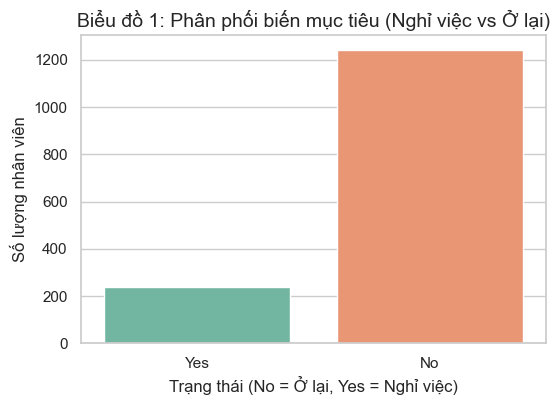

Tỷ lệ % các lớp:
 Attrition
No     83.918919
Yes    16.081081
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2') # Thay 'left' bằng 'Attrition'
plt.title('Biểu đồ 1: Phân phối biến mục tiêu (Nghỉ việc vs Ở lại)', fontsize=14)
plt.xlabel('Trạng thái (No = Ở lại, Yes = Nghỉ việc)')
plt.ylabel('Số lượng nhân viên')
plt.show()

# Đừng quên đổi tên ở dòng in % nữa nhé
print("Tỷ lệ % các lớp:\n", df['Attrition'].value_counts(normalize=True) * 100)

## Biểu đồ 2: Phân tích Hài lòng công việc và Làm thêm giờ (OverTime)

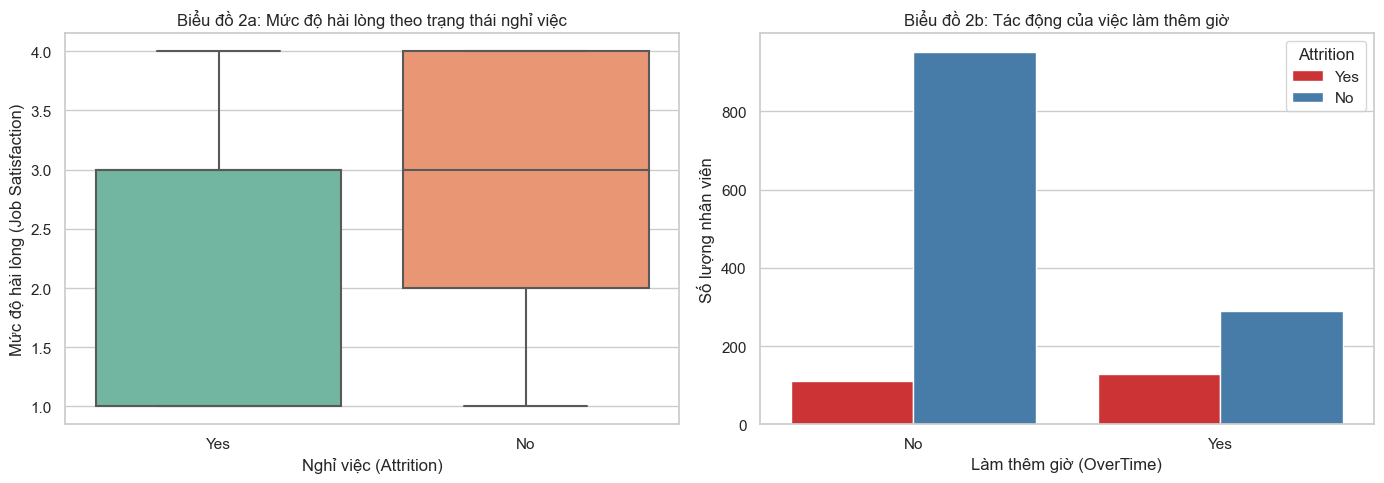

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị boxplot: Mức độ hài lòng công việc (JobSatisfaction)
sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', palette='Set2', ax=axes[0])
axes[0].set_title('Biểu đồ 2a: Mức độ hài lòng theo trạng thái nghỉ việc')
axes[0].set_xlabel('Nghỉ việc (Attrition)')
axes[0].set_ylabel('Mức độ hài lòng (Job Satisfaction)')

# Đồ thị countplot: Tác động của làm thêm giờ (OverTime)
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set1', ax=axes[1])
axes[1].set_title('Biểu đồ 2b: Tác động của việc làm thêm giờ')
axes[1].set_xlabel('Làm thêm giờ (OverTime)')
axes[1].set_ylabel('Số lượng nhân viên')

plt.tight_layout()
plt.show()

## Biểu đồ 3: Phân tích theo Phân khúc lương (SalarySlab)

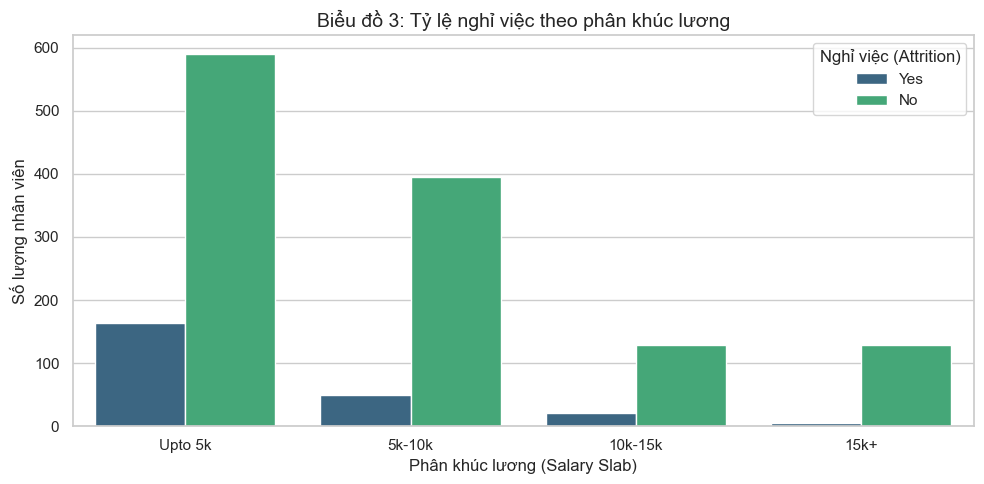

In [20]:
plt.figure(figsize=(10, 5))

# Sử dụng cột SalarySlab có sẵn trong dữ liệu của bác
sns.countplot(data=df, x='SalarySlab', hue='Attrition', palette='viridis')
plt.title('Biểu đồ 3: Tỷ lệ nghỉ việc theo phân khúc lương', fontsize=14)
plt.xlabel('Phân khúc lương (Salary Slab)')
plt.ylabel('Số lượng nhân viên')
plt.legend(title='Nghỉ việc (Attrition)')

plt.tight_layout()
plt.show()